# 1. Import and Hardware Setup

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset

!pip install wandb -q
import wandb

!pip install tqdm ipywidgets -q
from tqdm.auto import tqdm 

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [26]:
DATA_PATH = './Data'
SAVE_PATH = './Save'

# 2. Hyperparameters

In [27]:
IMG_SIZE = 224
IN_CHANNELS = 3
BATCH_SIZE = 256
NUM_CLASSES = 101

EPOCHS = 150
LR = 0.1


# 3. Data Preparation

In [28]:
stats = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(IMG_SIZE),
    transforms.AutoAugment(transforms.AutoAugmentPolicy.IMAGENET),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(*stats),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.33), ratio=(0.3, 3.3), value='random')
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

In [29]:
# Download train data first without transform
dummy_data = datasets.Food101(root=DATA_PATH, split='train', download=True)

# Split the train data into train and validation data
train_size = int(0.8 * len(dummy_data))
val_size = len(dummy_data) - train_size
train_subset_tmp, val_subset_tmp = random_split(dummy_data, [train_size, val_size])

# Extract indices from them
train_idx = train_subset_tmp.indices
val_idx = val_subset_tmp.indices

# Create Subsets using the indices
train_dataset = datasets.Food101(root=DATA_PATH, split='train',
                                download=False, transform=train_transform)
val_dataset = datasets.Food101(root=DATA_PATH, split='train',
                                download=False, transform=test_transform)

# Create Subsets using the indices
train_subset = Subset(train_dataset, train_idx)
val_subset = Subset(val_dataset, val_idx)

# Download Test Dataset
test_dataset = datasets.Food101(root=DATA_PATH, split='test',
                                download=True, transform=test_transform)

In [30]:
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True, persistent_workers=True)

val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=1, pin_memory=True, persistent_workers=True)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=1, pin_memory=True, persistent_workers=True)

# 4. Model Architecture

![ResNet](ResNet.png)
![ResNet2](ResNet2.png)

In [31]:
class BasisBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False,
        )

        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != self.expansion * out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    self.expansion * out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False,
                ),
                nn.BatchNorm2d(self.expansion * out_channels),
            )

    def forward(self, x):
        identity = x
        
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))

        identity = self.shortcut(identity)
        x += identity
        x = self.relu(x)

        return x

In [32]:
class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=NUM_CLASSES):
        super().__init__()
        self.in_channels = 64
        
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)
        
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)
        
        self._initialize_weights()

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_channels, out_channels, s))
            self.in_channels = out_channels * block.expansion
            
        return nn.Sequential(*layers)
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)
        
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        
        x = self.avg_pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        
        return x
    
def ResNet18(num_classes=NUM_CLASSES):
    return ResNet(BasisBlock, [2, 2, 2, 2], num_classes)

In [33]:
model = ResNet18(num_classes=NUM_CLASSES).to(device)
print(f"Total parameters: {(sum(p.numel() for p in model.parameters())/1e6):.2f}M")

# Use multiple GPUs if available
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

Total parameters: 11.23M
Using 2 GPUs


# 5. Training Preparation

In [ ]:
class EarlyStopping(nn.Module):
    def __init__(self, patience=10, delta=0, verbose=False, save_path='best_checkpoint.pth'):
        self.patience = patience
        self.delta = delta
        self.verbose = verbose
        self.save_path = save_path
        
        self.best_loss = None
        self.early_stop = False
        self.counter = 0
    
    def __call__(self, val_loss, model):
        # For the first epoch
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        
        # When the loss didnt reduce as expect
        elif val_loss > self.best_loss - self.delta:
            self.counter += 1
            print(f"Early Stopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        
        # The loss reduced as expect
        else:
            self.counter = 0
            self.best_loss = val_loss
            self.save_checkpoint(model)
    
    def save_checkpoint(self, model):
        if self.verbose:
            print("Saving best checkpoint ... ")
            
        state_dict = model.module.state_dict() if hasattr(model, 'module') else model.state_dict()
        torch.save(state_dict, self.save_path)

In [35]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, "min", patience= 3, factor=0.1)

scaler =  torch.amp.GradScaler(device)

In [36]:
def train(model, loader, criterion, optimizer, scheduler):
    model.train()
    train_loss, train_acc = 0, 0
    loop = tqdm(loader, desc="Training", leave=False)
    
    for x, y in loop:
        # Move data to device
        x, y = x.to(device), y.to(device)
        # Zero out the Gradients of last batch
        optimizer.zero_grad(set_to_none=True)
        
        # Get output and loss with Mixed Precision
        with torch.amp.autocast(device_type=device.type):
            out = model(x)
            loss = criterion(out, y)
            
        # Upscale the loss and backpropagate
        scaler.scale(loss).backward()
        
        # Downscale and clip the Gradients
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Check if the Gradients are valid and update the Model Weights
        scaler.step(optimizer)
        
        # Update the scale factor
        scaler.update()
        
        # Sum up loss and acc
        train_loss += loss.detach() * x.size(0)
        train_acc += (out.argmax(1) == y).sum()
        
    return train_loss.item() / len(loader.dataset), train_acc.item() / len(loader.dataset)

In [37]:
def validate(model, loader, criterion):
    model.eval()
    val_loss = 0
    loop = tqdm(loader, desc="Validation", leave=False)
    
    for x, y in loop:
        x, y = x.to(device), y.to(device)
        
        with torch.no_grad():
            out = model(x)
            loss = criterion(out, y)
            
        val_loss += loss.detach() * x.size(0)
        
    return val_loss.item() / len(loader.dataset)

In [38]:
def test(model, loader):
    model.eval()
    test_acc = 0
    loop = tqdm(loader, desc="Testing", leave=False)
    
    for x, y in loop:
        x, y = x.to(device), y.to(device)
        
        with torch.no_grad():
            out = model(x)
            
        test_acc += (out.argmax(1) == y).sum()
        
    return test_acc.item() / len(loader.dataset)

# 6. Train

In [39]:
train_losses, val_losses = [], []
train_accuracies, test_accuracies = [], []
early_stopping = EarlyStopping(patience=10)

for epoch in range(EPOCHS):
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, scheduler)
    val_loss = validate(model, val_loader, criterion)
    test_acc = test(model, test_loader)
    
    scheduler.step(val_loss)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    
    print(f"Epoch {epoch+1}/{EPOCHS}: train_loss: {train_loss:.2f}, val_loss: {val_loss:.2f}, " +
          f"train_acc: {train_acc:.2f}, test_acc: {test_acc:.2f}")
    
    early_stopping(val_loss, model)
    if early_stopping.early_stop:
        print("Early Stopping")
        break

Training:   0%|          | 0/237 [00:00<?, ?it/s]

Validation:   0%|          | 0/60 [00:00<?, ?it/s]

Testing:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 1/150: train_loss: 4.52, val_loss: 4.23, train_acc: 0.04, test_acc: 0.07


Training:   0%|          | 0/237 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/60 [00:00<?, ?it/s]

Testing:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 46/150: train_loss: 1.04, val_loss: 1.19, train_acc: 0.74, test_acc: 0.75


Training:   0%|          | 0/237 [00:00<?, ?it/s]

KeyboardInterrupt: 

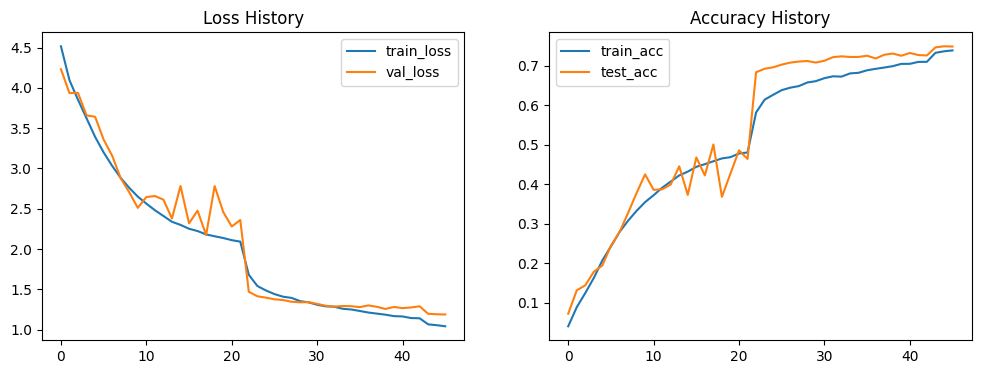

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label= 'train_loss')
plt.plot(val_losses, label = 'val_loss')
plt.title('Loss History')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label = 'train_acc')
plt.plot(test_accuracies, label = 'test_acc')
plt.title('Accuracy History')
plt.legend()